In [1]:
#!pip install pandas matplotlib seaborn 

In [2]:
# biblioteki
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import csv
import re

sns.set_theme(style="whitegrid", context="notebook")


##  Tworzenie datasetów

In [3]:
# dataset OpenAlex
df_ap = pd.read_csv('datasets/OpenAlex.csv')
df_ap = df_ap[df_ap['authorships.countries'].str.contains('PL', na=False, case=False)]
df_ap.head()


,id,abstract,authorships.author.display_name,authorships.author.id,authorships.author.orcid,authorships.countries,authorships.institutions.display_name,authorships.institutions.id,authorships.is_corresponding,best_oa_location.license,...,open_access.is_oa,open_access.oa_status,primary_location.source.display_name,primary_location.source.id,primary_location.source.issn_l,primary_location.source.type,primary_topic.display_name,publication_date,publication_year,type
194,https://openalex.org/W4312552362,The increase in the volume of user-generated c...,Huyen Trang Phan|Ngoc Thanh Nguyên|Dosam Hwang,https://openalex.org/A5028824441|https://opena...,https://orcid.org/0000-0002-7466-9562|https://...,KR|PL|VN|KR,Yeungnam University|Trường ĐH Nguyễn Tất Thành...,https://openalex.org/I55240360|https://openale...,True|False|False,cc-by,...,True,gold,IEEE Access,https://openalex.org/S2485537415,2169-3536,journal,Sentiment Analysis and Opinion Mining,2022-01-01,2022.0,article
215,https://openalex.org/W3193808040,NaN,Krzysztof Fiok|Waldemar Karwowski|Edgar Gutiér...,https://openalex.org/A5061282814|https://opena...,https://orcid.org/0000-0001-5711-1498|https://...,US|US|US|PL,University of Central Florida|University of Ce...,https://openalex.org/I106165777|https://openal...,False|False|True|False,NaN,...,False,closed,Expert Systems with Applications,https://openalex.org/S13144211,0957-4174,journal,Topic Modeling,2021-08-20,2021.0,article
594,https://openalex.org/W4402137751,Automatic polarity prediction is a challenging...,Shanza Zafar Malik|Khalid Iqbal|Muhammad Imran...,https://openalex.org/A5114219273|https://opena...,|https://orcid.org/0000-0002-2742-5127|https:/...,PK|PK|PK|PK|PK|PK|PL,COMSATS University Islamabad|COMSATS Universit...,https://openalex.org/I16076960|https://openale...,True|False|False|False|False|False|False,cc-by,...,True,gold,PeerJ Computer Science,https://openalex.org/S4210178049,2376-5992,journal,Sentiment Analysis and Opinion Mining,2024-09-02,2024.0,article
828,https://openalex.org/W3163392354,We build on abduction-based explanations for m...,Emanuele La Malfa|Agnieszka M. Zbrzezny|Rhiann...,https://openalex.org/A5067881408|https://opena...,https://orcid.org/0000-0002-6254-0470|https://...,GB|GB|GB|PL|GB|GB,University of Oxford|University of Oxford|Univ...,https://openalex.org/I40120149|https://openale...,True|False|False|False|False,NaN,...,True,gold,NaN,NaN,NaN,NaN,Explainable Artificial Intelligence (XAI),2021-08-01,2021.0,preprint
842,https://openalex.org/W3158455298,The COVID-19 pandemic has changed our lifestyl...,Krzysztof Fiok|Waldemar Karwowski|Edgar Gutiér...,https://openalex.org/A5061282814|https://opena...,https://orcid.org/0000-0001-5711-1498|https://...,US|US|US|US|SA|US|FR|PL|US,University of Central Florida|University of Ce...,https://openalex.org/I106165777|https://openal...,False|False|False|False|False|True|False|False...,cc-by,...,True,gold,International Journal of Environmental Researc...,https://openalex.org/S15239247,1660-4601,journal,COVID-19 and Mental Health,2021-04-25,2021.0,article


In [4]:
print(df_ap.columns)

Index(['id', 'abstract', 'authorships.author.display_name',
       'authorships.author.id', 'authorships.author.orcid',
       'authorships.countries', 'authorships.institutions.display_name',
       'authorships.institutions.id', 'authorships.is_corresponding',
       'best_oa_location.license', 'cited_by_count',
       'corresponding_institution_ids', 'display_name', 'doi',
       'funders.display_name', 'fwci', 'ids.pmid', 'is_retracted', 'language',
       'open_access.is_oa', 'open_access.oa_status',
       'primary_location.source.display_name', 'primary_location.source.id',
       'primary_location.source.issn_l', 'primary_location.source.type',
       'primary_topic.display_name', 'publication_date', 'publication_year',
       'type'],
      dtype='str')


In [5]:
#dateset Scopus

df_sc = pd.read_csv('datasets/scopus_export_Mar 19-2026.csv')
df_sc = df_sc[df_sc['Affiliations'].str.contains('Poland', na=False, case=False)]
df_sc.head()

,Authors,Author full names,Author(s) ID,Title,Year,Source title,Volume,Issue,Art. No.,Page start,...,ISBN,CODEN,PubMed ID,Language of Original Document,Abbreviated Source Title,Document Type,Publication Stage,Open Access,Source,EID
139,Mazur R.,"Mazur, Rafał (57224214001)",57224214001,Russo-Ukrainian War in Polish Political Discou...,2025,LingVaria,20,2,NaN,143,...,NaN,NaN,NaN,Polish,LingVaria,Article,Final,All Open Access; Gold Open Access; Green Open ...,Scopus,2-s2.0-105023985460
301,Meler A.,"Meler, Andrzej (57223097428)",57223097428,"Two voices, one war: NLP and LDA for sociologi...",2026,Social Network Analysis and Mining,16,1,7,NaN,...,NaN,NaN,NaN,English,Soc. Netw. Analysis Min.,Article,Final,All Open Access; Hybrid Gold Open Access,Scopus,2-s2.0-105026837661
547,Jaworski K.,"Jaworski, Krystian (57203852409)",57203852409,Measuring Inflation Expectations Using Artific...,2025,Computational Economics,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,English,Comput. Econ.,Article,Article in press,All Open Access; Hybrid Gold Open Access,Scopus,2-s2.0-105024946250
558,Michalak J.,"Michalak, Joanna (59362690800)",59362690800,Affect Indicators for Stock Market Forecasting,2025,Central European Economic Journal,12,59,NaN,412,...,NaN,NaN,NaN,English,Central Eur. Econ. J.,Article,Final,All Open Access; Hybrid Gold Open Access,Scopus,2-s2.0-105026247448
664,Xie X.; Osińska M.,"Xie, Xiaohong (58393654300); Osińska, Magdalen...",58393654300; 23967115200,Decoding public sentiment on pension policies ...,2025,Bank i Kredyt,56,5,NaN,613,...,NaN,NaN,NaN,English,Bank i Kredyt,Article,Final,NaN,Scopus,2-s2.0-105021232756


In [6]:
print(df_sc.columns)

Index(['Authors', 'Author full names', 'Author(s) ID', 'Title', 'Year',
       'Source title', 'Volume', 'Issue', 'Art. No.', 'Page start', 'Page end',
       'Cited by', 'DOI', 'Link', 'Affiliations', 'Authors with affiliations',
       'Abstract', 'Author Keywords', 'Index Keywords',
       'Molecular Sequence Numbers', 'Chemicals/CAS', 'Tradenames',
       'Manufacturers', 'Funding Details', 'Funding Texts', 'References',
       'Correspondence Address', 'Editors', 'Publisher', 'Sponsors',
       'Conference name', 'Conference date', 'Conference location',
       'Conference code', 'ISSN', 'ISBN', 'CODEN', 'PubMed ID',
       'Language of Original Document', 'Abbreviated Source Title',
       'Document Type', 'Publication Stage', 'Open Access', 'Source', 'EID'],
      dtype='str')


In [7]:
# dataset web of science
params = {
    'sep': '\t',
    'quoting': csv.QUOTE_NONE,
    'encoding': 'utf-8', 
    'index_col': False,
    'on_bad_lines': 'warn'
}

files = [
    r'datasets/WebOfScience1-1000.csv',
    r'datasets/WebOfScience1001-2000.csv',
    r'datasets/WebOfScience2001-2100.csv'
]

df_list = []
for f in files:
    temp_df = pd.read_csv(f, **params)
    df_list.append(temp_df)

df_wos = pd.concat(df_list, axis=0, ignore_index=True)


mapping = {
    'FN': 'File Name',
    'VR': 'Version Number',
    'PT': 'Publication Type',
    'AU': 'Authors',
    'AF': 'Author Full Name',
    'BA': 'Book Authors',
    'BF': 'Book Authors Full Name',
    'CA': 'Group Authors',
    'GP': 'Book Group Authors',
    'BE': 'Editors',
    'TI': 'Document Title',
    'SO': 'Publication Name',
    'SE': 'Book Series Title',
    'BS': 'Book Series Subtitle',
    'LA': 'Language',
    'DT': 'Document Type',
    'CT': 'Conference Title',
    'CY': 'Conference Date',
    'CL': 'Conference Location',
    'SP': 'Conference Sponsors',
    'HO': 'Conference Host',
    'DE': 'Author Keywords',
    'ID': 'Keywords Plus®',
    'AB': 'Abstract',
    'C1': 'Author Address',
    'RP': 'Reprint Address',
    'EM': 'E-mail Address',
    'RI': 'ResearcherID Number',
    'OI': 'ORCID Identifier (Open Researcher and Contributor ID)',
    'FU': 'Funding Agency and Grant Number',
    'FX': 'Funding Text',
    'CR': 'Cited References',
    'NR': 'Cited Reference Count',
    'TC': 'Web of Science Core Collection Times Cited Count',
    'Z9': 'Total Times Cited Count',
    'U1': 'Usage Count (Last 180 Days)',
    'U2': 'Usage Count (Since 2013)',
    'PU': 'Publisher',
    'PI': 'Publisher City',
    'PA': 'Publisher Address',
    'SN': 'International Standard Serial Number (ISSN)',
    'EI': 'Electronic International Standard Serial Number (eISSN)',
    'BN': 'International Standard Book Number (ISBN)',
    'J9': '29-Character Source Abbreviation',
    'JI': 'ISO Source Abbreviation',
    'PD': 'Publication Date',
    'PY': 'Year Published',
    'VL': 'Volume',
    'IS': 'Issue',
    'SI': 'Special Issue',
    'PN': 'Part Number',
    'SU': 'Supplement',
    'MA': 'Meeting Abstract',
    'BP': 'Beginning Page',
    'EP': 'Ending Page',
    'AR': 'Article Number',
    'DI': 'Digital Object Identifier (DOI)',
    'D2': 'Book Digital Object Identifier (DOI)',
    'PG': 'Page Count',
    'P2': 'Chapter Count (Book Citation Index)',
    'WC': 'Web of Science Categories',
    'SC': 'Research Areas',
    'GA': 'Document Delivery Number',
    'UT': 'Accession Number',
    'PM': 'PubMed ID',
    'ER': 'End of Record',
    'EF': 'End of File'}


df_wos = df_wos.rename(columns=mapping)

print(f"The file has {len(df_wos)} records.")

The file has 2100 records.


In [8]:
df_wos = df_wos[
    df_wos['Author Address'].str.contains('Poland', na=False, case=False) | 
    df_wos['Reprint Address'].str.contains('Poland', na=False, case=False)
]

In [9]:
df_wos.head()

,Publication Type,Authors,Book Authors,Editors,Book Group Authors,Author Full Name,Book Authors Full Name,Group Authors,Document Title,Publication Name,...,Web of Science Categories,WE,Research Areas,Document Delivery Number,PubMed ID,OA,HC,HP,DA,Accession Number
55,C,"Wójcik, M; Horzyk, A; Bulanda, D",NaN,"Mantoro, T; Lee, M; Ayu, MA; Wong, KW; Hidayan...",NaN,"Wojcik, Maciej; Horzyk, Adrian; Bulanda, Daniel",NaN,NaN,Associative Graphs for Fine-Grained Text Senti...,"NEURAL INFORMATION PROCESSING, ICONIP 2021, PT II",...,"Computer Science, Artificial Intelligence; Com...",Conference Proceedings Citation Index - Scienc...,Computer Science,BY3KD,NaN,NaN,NaN,NaN,2026-03-19,WOS:001419489900021
85,J,"Malik, SZ; Iqbal, K; Sharif, M; Shah, YA; Khal...",NaN,NaN,NaN,"Malik, Shanza Zafar; Iqbal, Khalid; Sharif, Mu...",NaN,NaN,Attention-aware with stacked embedding for sen...,PEERJ COMPUTER SCIENCE,...,"Computer Science, Artificial Intelligence; Com...",Science Citation Index Expanded (SCI-EXPANDED),Computer Science,E6Z7E,39314683.0,"Green Submitted, gold",NaN,NaN,2026-03-19,WOS:001304474800001
174,C,"Kedzierska, M; Spytek, M; Kurek, M; Sawicki, J...",NaN,"Sachdeva, S; Watanobe, Y",NaN,"Kedzierska, Maria; Spytek, Mikolaj; Kurek, Mar...",NaN,NaN,Topic Modeling Applied to Reddit Posts,"BIG DATA ANALYTICS IN ASTRONOMY, SCIENCE, AND ...",...,"Computer Science, Artificial Intelligence; Com...",Conference Proceedings Citation Index - Scienc...,Computer Science,BX4XI,NaN,NaN,NaN,NaN,2026-03-19,WOS:001295939700002
374,J,"Phan, HT; Tran, VC; Nguyen, NT; Hwang, D",NaN,NaN,NaN,Huyen Trang Phan; Van Cuong Tran; Ngoc Thanh N...,NaN,NaN,Improving the Performance of Sentiment Analysi...,IEEE ACCESS,...,"Computer Science, Information Systems; Enginee...",Science Citation Index Expanded (SCI-EXPANDED),Computer Science; Engineering; Telecommunications,LB6IE,NaN,"Green Submitted, gold",NaN,NaN,2026-03-19,WOS:000524736700024
505,J,"Meler, A",NaN,NaN,NaN,"Meler, Andrzej",NaN,NaN,"Two voices, one war: NLP and LDA for sociologi...",SOCIAL NETWORK ANALYSIS AND MINING,...,"Computer Science, Information Systems",Emerging Sources Citation Index (ESCI),Computer Science,AS2EF,NaN,hybrid,NaN,NaN,2026-03-19,WOS:001655509900001


# Świat

## Chronologiczny rozkład publikacji

In [10]:
# open alex 
yearly_counts_op = df_ap['publication_year'].value_counts().sort_index()



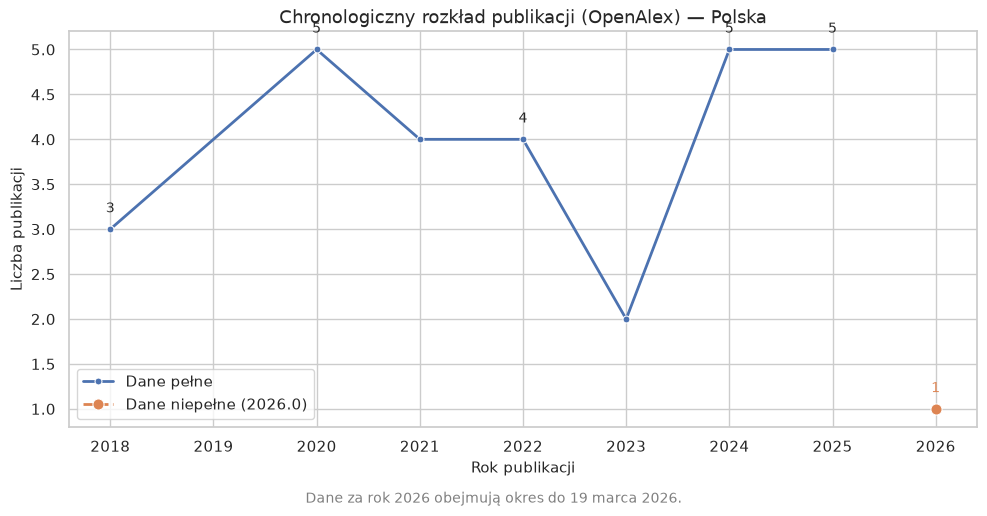

In [11]:
# Ustawienia globalne — muszą być PRZED plt.figure()
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11

# Ostatni rok w danych
last_year = yearly_counts_op.index.max()
# Dane pełne
yc_full = yearly_counts_op[yearly_counts_op.index < last_year]
# Dane niepełne (ostatni rok)
yc_partial = yearly_counts_op[yearly_counts_op.index == last_year]

fig, ax = plt.subplots(figsize=(10, 5))

# Linia dla danych pełnych
sns.lineplot(
    x=yc_full.index, y=yc_full.values,
    marker="o", linewidth=2, markersize=5,
    label="Dane pełne", ax=ax
)

# Linia dla danych niepełnych (ostatni rok)
sns.lineplot(
    x=yc_partial.index, y=yc_partial.values,
    marker="o", markersize=8, linewidth=2, linestyle="--",
    label=f"Dane niepełne ({last_year})", ax=ax
)

# --- Etykiety wartości co 2 lata ---
offset = (max(yc_full.values) * 0.03) if len(yc_full) > 0 else 0

for x, y in zip(yc_full.index, yc_full.values):
    if x % 2 == 0 or x == 2025:  # Etykiety co 2 lata lub dla ostatniego roku
        ax.text(
            x, y + offset,
            str(y), ha='center', va='bottom',
            fontsize=10
        )

# --- Etykieta dla ostatniego roku ---
for x, y in zip(yc_partial.index, yc_partial.values):
    ax.text(
        x, y + offset,
        str(y), ha='center', va='bottom',
        fontsize=10, color=sns.color_palette()[1]
    )

# Informacja o niepełnym roku
fig.text(
    0.5, -0.02,
    "Dane za rok 2026 obejmują okres do 19 marca 2026.",
    ha='center', fontsize=10, color='gray'
)

ax.set(title='Chronologiczny rozkład publikacji (OpenAlex) — Polska',
       xlabel='Rok publikacji', ylabel='Liczba publikacji')
ax.legend()
fig.tight_layout()
plt.show()

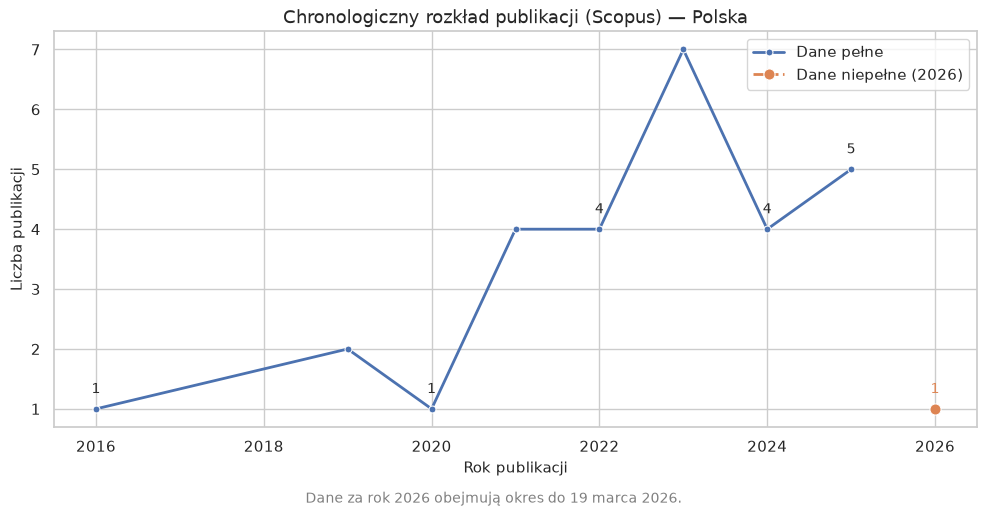

In [12]:
# Dane Scopus
yearly_counts_sc = df_sc['Year'].value_counts().sort_index()

# Ostatni rok
last_year_sc = yearly_counts_sc.index.max()

# Dane pełne i niepełne
sc_full = yearly_counts_sc[yearly_counts_sc.index < last_year_sc]
sc_partial = yearly_counts_sc[yearly_counts_sc.index == last_year_sc]

fig, ax = plt.subplots(figsize=(10, 5))

# Linia dla danych pełnych
sns.lineplot(
    x=sc_full.index, y=sc_full.values,
    marker="o", linewidth=2, markersize=5,
    label="Dane pełne", ax=ax
)

# Linia dla danych niepełnych
sns.lineplot(
    x=sc_partial.index, y=sc_partial.values,
    marker="o", markersize=8, linewidth=2, linestyle="--",
    label=f"Dane niepełne ({last_year_sc})", ax=ax
)

# Offset etykiet (3% wysokości)
offset_sc = (max(sc_full.values) * 0.03) if len(sc_full) > 0 else 0

# Etykiety co 2 lata
for x, y in zip(sc_full.index, sc_full.values):
    if x % 2 == 0 or x == 2025:  # Etykiety co 2 lata lub dla ostatniego roku
        ax.text(
            x, y + offset_sc,
            str(y), ha='center', va='bottom', fontsize=10
        )

# Etykieta dla ostatniego roku
for x, y in zip(sc_partial.index, sc_partial.values):
    ax.text(
        x, y + offset_sc,
        str(y), ha='center', va='bottom',
        fontsize=10, color=sns.color_palette()[1]
    )

# Informacja o niepełnym roku
fig.text(
    0.5, -0.02,
    "Dane za rok 2026 obejmują okres do 19 marca 2026.",
    ha='center', fontsize=10, color='gray'
)

ax.set(title='Chronologiczny rozkład publikacji (Scopus) — Polska',
       xlabel='Rok publikacji', ylabel='Liczba publikacji')
ax.legend()
fig.tight_layout()
plt.show()

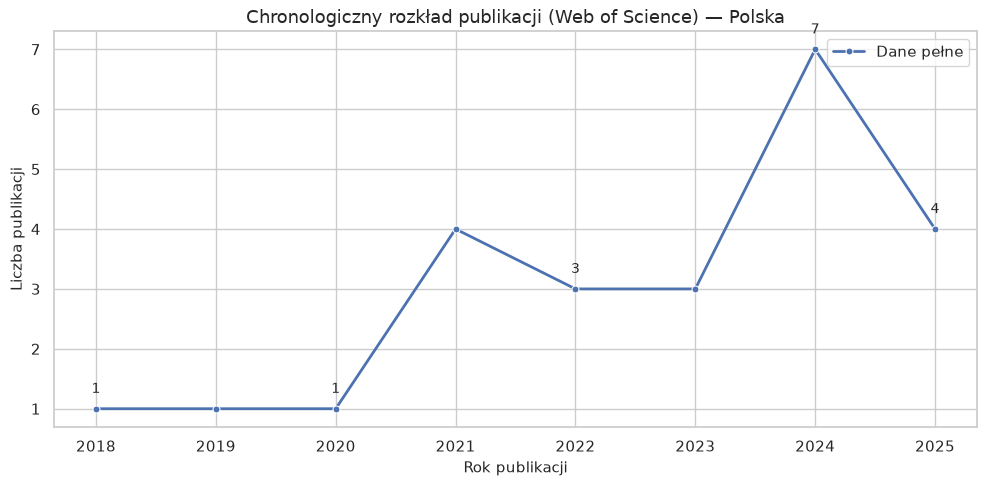

In [40]:
# Dane Web of Science
yearly_counts_wof = df_wos['Year Published'].value_counts().sort_index()



# Dane pełne i niepełne
wof_full = yearly_counts_wof[yearly_counts_wof.index]

fig, ax = plt.subplots(figsize=(10, 5))

# Linia dla danych pełnych
sns.lineplot(
    x=wof_full.index, y=wof_full.values,
    marker="o", linewidth=2, markersize=5,
    label="Dane pełne", ax=ax
)



# Offset etykiet (3% wysokości)
offset_wof = (max(wof_full.values) * 0.03) if len(wof_full) > 0 else 0

# Etykiety co 2 lata
for x, y in zip(wof_full.index, wof_full.values):
    if x % 2 == 0 or x == 2025:  # Etykiety co 2 lata lub dla ostatniego roku
        ax.text(
            x, y + offset_wof,
            str(y), ha='center', va='bottom', fontsize=10
        )

ax.set(title='Chronologiczny rozkład publikacji (Web of Science) — Polska',
       xlabel='Rok publikacji', ylabel='Liczba publikacji')
ax.legend()
fig.tight_layout()
plt.show()

## Rozkład tematu według dyscyplin naukowych


In [14]:
# Open Alex
df_op_areas = df_ap['primary_topic.display_name'].dropna().value_counts()

print("Top 10 dziedzin w OpenAlex:")
print(df_op_areas.head(10))

Top 10 dziedzin w OpenAlex:
primary_topic.display_name
Misinformation and Its Impacts                5
Sentiment Analysis and Opinion Mining         3
Topic Modeling                                2
Social Media and Politics                     2
Digital Marketing and Social Media            2
Explainable Artificial Intelligence (XAI)     1
COVID-19 and Mental Health                    1
Evolutionary Psychology and Human Behavior    1
Computational and Text Analysis Methods       1
Advanced Text Analysis Techniques             1
Name: count, dtype: int64


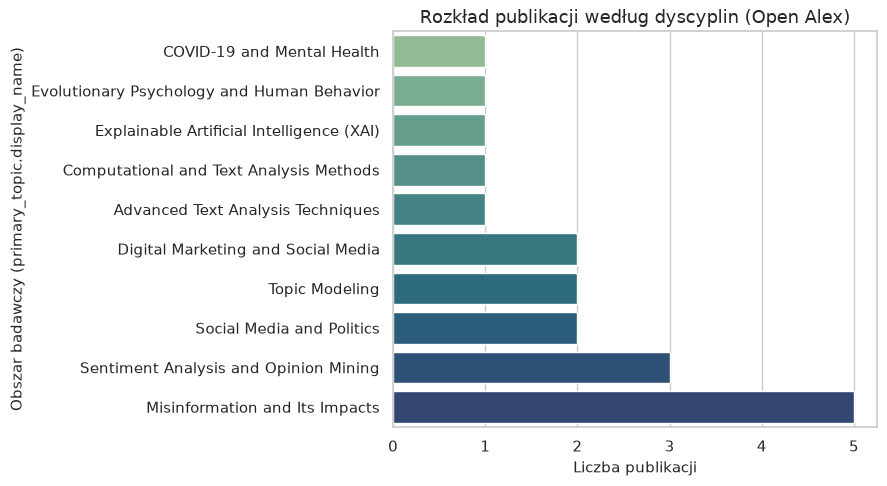

In [15]:
top = df_op_areas.head(10).sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(x=top.values, y=top.index, hue=top.index,
            palette="crest", legend=False, ax=ax)
ax.set(title='Rozkład publikacji według dyscyplin (Open Alex)',
       xlabel='Liczba publikacji',
       ylabel='Obszar badawczy (primary_topic.display_name)')
fig.tight_layout()
plt.show()

In [16]:
# Scopus
df_sc_areas = df_sc['Source title'].dropna().value_counts()
print("Top 10 dziedzin w Scopus:")
print(df_sc_areas.head(10))

Top 10 dziedzin w Scopus:
Source title
Lecture Notes in Computer Science (including subseries Lecture Notes in Artificial Intelligence and Lecture Notes in Bioinformatics)    4
Frontiers in Public Health                                                                                                              2
LingVaria                                                                                                                               1
Social Network Analysis and Mining                                                                                                      1
Computational Economics                                                                                                                 1
Central European Economic Journal                                                                                                       1
Bank i Kredyt                                                                                                                        

C:\Users\mmakr\AppData\Local\Temp\ipykernel_26436\136970634.py:8: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


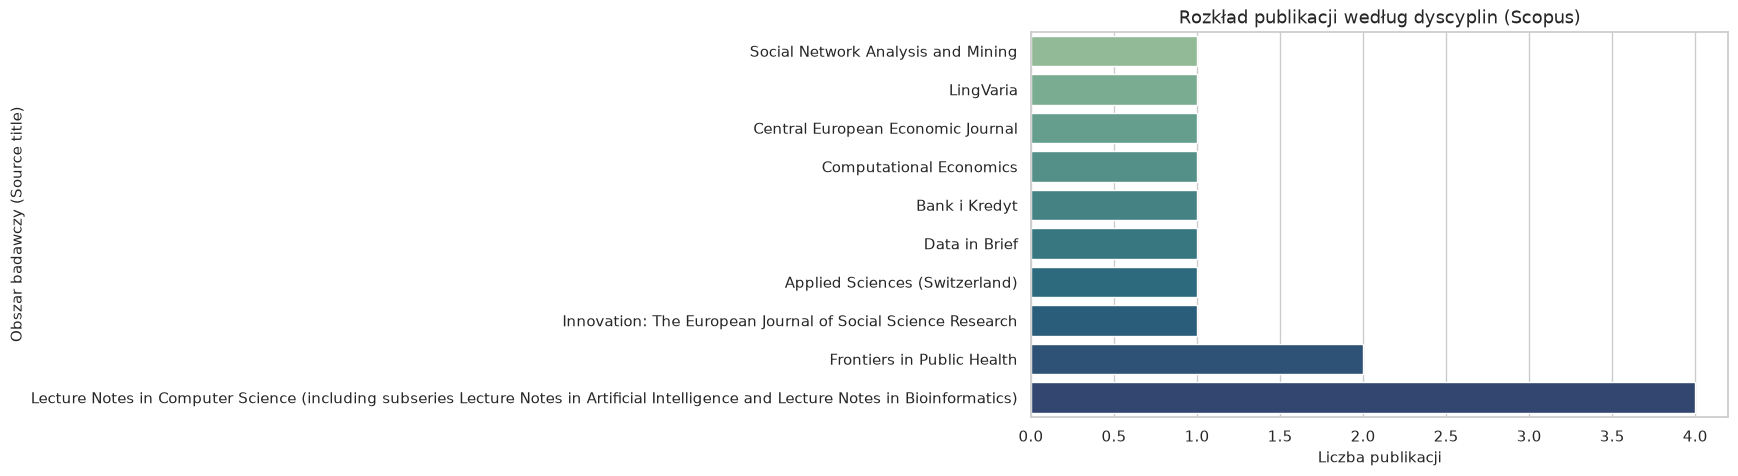

In [17]:
top = df_sc_areas.head(10).sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(x=top.values, y=top.index, hue=top.index,
            palette="crest", legend=False, ax=ax)
ax.set(title='Rozkład publikacji według dyscyplin (Scopus)',
       xlabel='Liczba publikacji',
       ylabel='Obszar badawczy (Source title)')
fig.tight_layout()
plt.show()

In [18]:
# Web of Science
df_wos_areas = df_wos['Research Areas']
df_wos_areas.dropna()
df_wos_areas.head()

55                                      Computer Science
85                                      Computer Science
174                                     Computer Science
374    Computer Science; Engineering; Telecommunications
505                                     Computer Science
Name: Research Areas, dtype: str

In [19]:
# funkcja na podzielenie dziedzin 
def get_wos_areas(area_text):
    areas = str(area_text).split(';')
    return [area.strip() for area in areas if area.strip() != '']

In [20]:
df_wos_areas = df_wos_areas.apply(get_wos_areas)
wos_areas_counts = df_wos_areas.explode().value_counts()
print("Top 10 dziedzin w Web of Science: ")
print(wos_areas_counts.head(10))

Top 10 dziedzin w Web of Science: 
Research Areas
Computer Science                               10
Engineering                                     6
Operations Research & Management Science        2
Physics                                         2
Public, Environmental & Occupational Health     2
Imaging Science & Photographic Technology       2
Telecommunications                              1
Chemistry                                       1
Materials Science                               1
Science & Technology - Other Topics             1
Name: count, dtype: int64


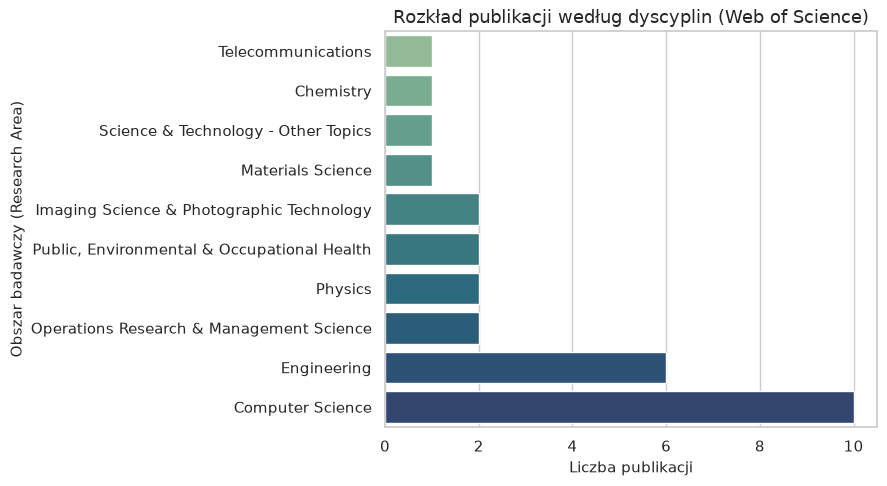

In [21]:
top = wos_areas_counts.head(10).sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(x=top.values, y=top.index, hue=top.index,
            palette="crest", legend=False, ax=ax)
ax.set(title='Rozkład publikacji według dyscyplin (Web of Science)',
       xlabel='Liczba publikacji',
       ylabel='Obszar badawczy (Research Area)')
fig.tight_layout()
plt.show()

## Rozkład wg języków publikacji


In [22]:

oa_lang_counts = df_ap['language'].dropna().value_counts().head(10)
sc_lang_counts = df_sc['Language of Original Document'].dropna().value_counts().head(10)
wos_lang_counts = df_wos['Language'].dropna().value_counts().head(10)


In [23]:

print("Top 5 języków (Open Alex)")
print(oa_lang_counts.head(5))
print("Top 5 języków (Scopus)")
print(sc_lang_counts.head(5))
print("Top 5 języków (Web of Science)")
print(wos_lang_counts.head(5))

Top 5 języków (Open Alex)
language
en    27
pl     2
Name: count, dtype: int64
Top 5 języków (Scopus)
Language of Original Document
English    28
Polish      1
Name: count, dtype: int64
Top 5 języków (Web of Science)
Language
English    24
Name: count, dtype: int64


## Liczba publikacji

In [24]:
total_openalex = len(df_ap)
total_scopus = len(df_sc)
total_wos = len(df_wos)

In [25]:

print("PODSUMOWANIE CAŁKOWITEJ LICZBY PUBLIKACJI ")
print(f"OpenAlex:        {total_openalex}")
print(f"Scopus:          {total_scopus}")
print(f"Web of Science:  {total_wos}")


PODSUMOWANIE CAŁKOWITEJ LICZBY PUBLIKACJI 
OpenAlex:        29
Scopus:          29
Web of Science:  24


## liczba współpracujących autorów

In [26]:
# open alex
df_openalex_authors = df_ap['authorships.author.id'].dropna()
all_authors_openalex = df_openalex_authors.str.split(';').explode().str.strip()
openalex_unique_authors_count = all_authors_openalex.nunique()
openalex_avg_authors_per_paper = len(all_authors_openalex) / len(df_openalex_authors)

In [27]:
# scopus
df_scopus_authors = df_sc['Author(s) ID'].dropna()
all_authors_scopus = df_scopus_authors.str.split(';').explode().str.strip()
scopus_unique_authors_count = all_authors_scopus.nunique()
scopus_avg_authors_per_paper = len(all_authors_scopus) / len(df_scopus_authors)


In [28]:
# Web of science
df_wos_authors = df_wos['ORCID Identifier (Open Researcher and Contributor ID)'].dropna()
all_authors_wos = df_wos_authors.str.split(';').explode().str.strip()
wos_unique_authors_count = all_authors_wos.nunique()
wos_avg_authors_per_paper = len(all_authors_wos) / len(df_wos_authors)

In [29]:
print("Open ALex ")
print(f"Całkowita liczba współpracujących autorów (unikalnych): {openalex_unique_authors_count}")
print(f"Średnia liczba autorów na jedną publikację:            {openalex_avg_authors_per_paper:.2f}")

print("Scopus")
print(f"Całkowita liczba współpracujących autorów (unikalnych): {scopus_unique_authors_count}")
print(f"Średnia liczba autorów na jedną publikację:            {scopus_avg_authors_per_paper:.2f}")

print("Web of Science")
print(f"Całkowita liczba współpracujących autorów (unikalnych): {wos_unique_authors_count}")
print(f"Średnia liczba autorów na jedną publikację:            {wos_avg_authors_per_paper:.2f}")





Open ALex 
Całkowita liczba współpracujących autorów (unikalnych): 25
Średnia liczba autorów na jedną publikację:            1.00
Scopus
Całkowita liczba współpracujących autorów (unikalnych): 123
Średnia liczba autorów na jedną publikację:            4.48
Web of Science
Całkowita liczba współpracujących autorów (unikalnych): 50
Średnia liczba autorów na jedną publikację:            3.17


In [30]:
print("Top 5 najbardziej płodnych autorów (Open Alex)")
print(all_authors_openalex.value_counts().head(5))

print("Top 5 najbardziej płodnych autorów (Scopus)")
print(all_authors_scopus.value_counts().head(5))
print("Top 5 najbardzij płodnych autorów (Web of Science)")
print(all_authors_wos.value_counts().head(5))

Top 5 najbardziej płodnych autorów (Open Alex)
authorships.author.id
https://openalex.org/A5061216470|https://openalex.org/A5003018886|https://openalex.org/A5051466394                                                                                                                                        4
https://openalex.org/A5022105396                                                                                                                                                                                                          2
https://openalex.org/A5028824441|https://openalex.org/A5047517734|https://openalex.org/A5032265881                                                                                                                                        1
https://openalex.org/A5061282814|https://openalex.org/A5068942141|https://openalex.org/A5056491924|https://openalex.org/A5050791292                                                                                            

## Wskaźnik produktywności na aktywne lata publikacji (Productivity per Active Year)

In [31]:

def calculate_productivity(name, years_series):
    if len(years_series) == 0:
        return None
    
    total_pub = len(years_series)
    active_years = years_series.nunique()
    
    productivity = total_pub / active_years
    
    return {
        "Base": name,
        "Total Publications": total_pub,
        "Active Years": active_years,
        "Productivity (Pub/Year)": round(productivity, 2)
    }



In [32]:
scopus_years = pd.to_numeric(df_sc['Year'], errors='coerce').dropna().astype(int)

wos_years = pd.to_numeric(df_wos['Year Published'], errors='coerce').dropna().astype(int)

oa_years = pd.to_numeric(df_ap['publication_year'], errors='coerce').dropna().astype(int)


In [33]:
productivit = []
productivit.append(calculate_productivity("Open Alex",oa_years))
productivit.append(calculate_productivity("Scopus",scopus_years))
productivit.append(calculate_productivity("Web of Science",wos_years))



In [34]:
print(productivit)

[{'Base': 'Open Alex', 'Total Publications': 29, 'Active Years': 8, 'Productivity (Pub/Year)': 3.62}, {'Base': 'Scopus', 'Total Publications': 29, 'Active Years': 9, 'Productivity (Pub/Year)': 3.22}, {'Base': 'Web of Science', 'Total Publications': 24, 'Active Years': 8, 'Productivity (Pub/Year)': 3.0}]


In [ ]:
df_productivity = pd.DataFrame([s for s in productivit if s is not None])

print("Productivity per Active Year")
print(df_productivity.to_string(index=False))

Productivity per Active Year
          Base  Total Publications  Active Years  Productivity (Pub/Year)
     Open Alex                  29             8                     3.62
        Scopus                  29             9                     3.22
Web of Science                  24             8                     3.00


## całkowita liczba cytowań (Total Citation Count)

In [ ]:
# Open Alex
oa_citations = pd.to_numeric(df_ap['cited_by_count'], errors='coerce').fillna(0)

total_cit_oa = oa_citations.sum()
avg_cit_oa = oa_citations.mean()


In [ ]:
# Scopus

scopus_citations = pd.to_numeric(df_sc['Cited by'], errors='coerce').fillna(0)

total_cit_scopus = scopus_citations.sum()
avg_cit_scopus = scopus_citations.mean()


In [ ]:
# Web of Science
wos_citations = pd.to_numeric(df_wos['Total Times Cited Count'], errors='coerce').fillna(0)

total_cit_wos = wos_citations.sum()
avg_cit_wos = wos_citations.mean()

In [39]:
print(f"Analiza cytowań")
print(f"Open Alex - Suma cytowań:{int(total_cit_oa)}")
print(f"Open Alex - Średnia na artykuł: {int(avg_cit_oa)}")

print("-" * 30)
print(f"Scopus - Suma cytowań: {int(total_cit_scopus)}")
print(f"Scopus - Średnia na artykuł: {avg_cit_scopus:.2f}")
print("-" * 30)
print(f"WoS - Suma cytowań:{int(total_cit_wos)}")
print(f"WoS - Średnia na artykuł:{avg_cit_wos:.2f}")


Analiza cytowań
Open Alex - Suma cytowań:201
Open Alex - Średnia na artykuł: 6
------------------------------
Scopus - Suma cytowań: 446
Scopus - Średnia na artykuł: 15.38
------------------------------
WoS - Suma cytowań:296
WoS - Średnia na artykuł:12.33
